In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

In [39]:
df = pd.read_csv('MLTempDataset.csv')

In [40]:
df

,Unnamed: 0,Datetime,Hourly_Temp
0,0,2022-01-04 00:00:00,20.867
1,1,2022-01-04 01:00:00,21.000
2,2,2022-01-04 02:00:00,20.867
3,3,2022-01-04 03:00:00,20.650
4,4,2022-01-04 04:00:00,20.400
...,...,...,...
7051,7051,2022-10-24 19:00:00,25.567
7052,7052,2022-10-24 20:00:00,25.183
7053,7053,2022-10-24 21:00:00,24.600
7054,7054,2022-10-24 22:00:00,23.986


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   7056 non-null   int64  
 1   Datetime     7056 non-null   object 
 2   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 165.5+ KB


In [42]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')
df.set_index('Datetime', inplace=True)

преобразуем столбец 'Datetime' в формат datetime с указанным форматом

In [43]:
df = df.drop('Unnamed: 0', axis=1)

т.к. индексом стал столбец Datetime, уберем уже ненужный столбец

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7056 entries, 2022-01-04 00:00:00 to 2022-10-24 23:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Hourly_Temp  7056 non-null   float64
dtypes: float64(1)
memory usage: 110.2 KB


In [45]:
df['Hourly_Temp'].describe()

,Hourly_Temp
count,7056.000000
mean,21.867468
std,6.737313
min,5.350000
25%,18.400000
50%,24.033000
75%,26.333000
max,36.500000


In [46]:
df1, df2 = train_test_split(df, test_size=0.2, shuffle=False)

разделим на тестовую и на обучающую выборки

In [47]:
train = df1
df1

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400
...,...
2022-08-26 23:00:00,26.850
2022-08-27 00:00:00,27.017
2022-08-27 01:00:00,26.960


In [48]:
test = df2
df2

,Hourly_Temp
Datetime,
2022-08-27 04:00:00,26.150
2022-08-27 05:00:00,25.867
2022-08-27 06:00:00,25.500
2022-08-27 07:00:00,25.233
2022-08-27 08:00:00,25.080
...,...
2022-10-24 19:00:00,25.567
2022-10-24 20:00:00,25.183
2022-10-24 21:00:00,24.600


<Axes: xlabel='Datetime'>

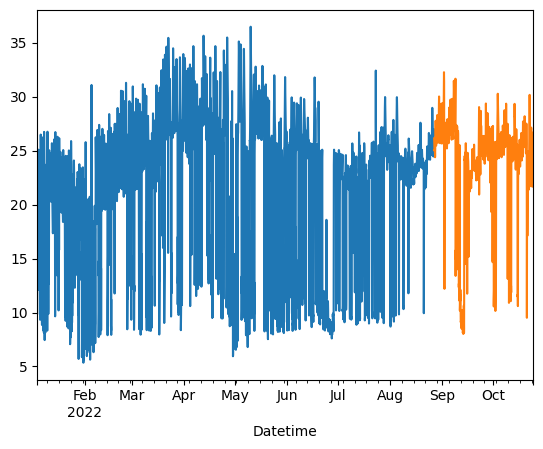

In [49]:
train['Hourly_Temp'].plot()
test['Hourly_Temp'].plot()

<Axes: xlabel='Datetime'>

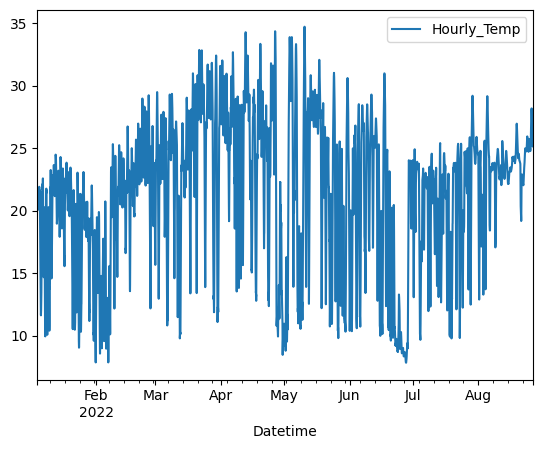

In [50]:
train.rolling(window=10).mean().plot()

<Axes: xlabel='Datetime'>

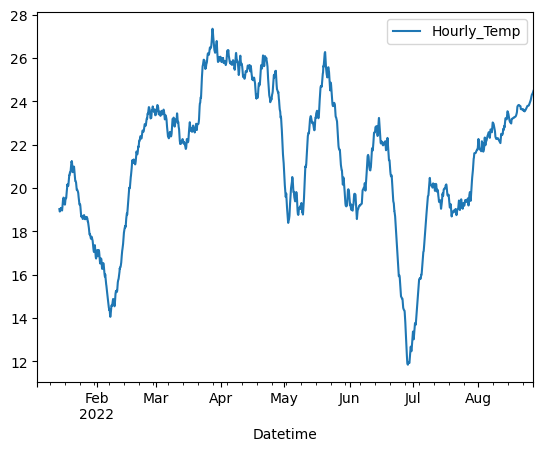

In [51]:
train.rolling(window=250).mean().plot()

сглаживание временного ряда методом скользящего среднего

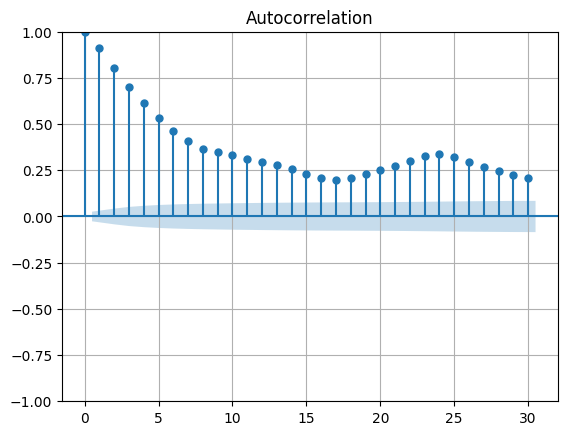

In [52]:
plot_acf(train, lags = 30)
plt.grid(True)
plt.show()

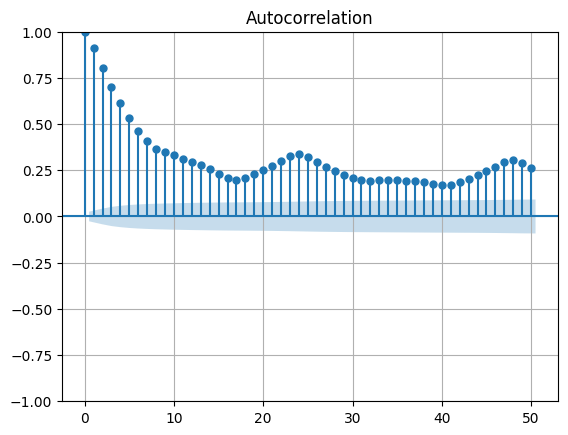

In [53]:
plot_acf(train, lags = 50)
plt.grid(True)
plt.show()

In [54]:
train.shift(1).head()

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,NaN
2022-01-04 01:00:00,20.867
2022-01-04 02:00:00,21.000
2022-01-04 03:00:00,20.867
2022-01-04 04:00:00,20.650


In [55]:
train.shift(-1)

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,21.000
2022-01-04 01:00:00,20.867
2022-01-04 02:00:00,20.650
2022-01-04 03:00:00,20.400
2022-01-04 04:00:00,20.100
...,...
2022-08-26 23:00:00,27.017
2022-08-27 00:00:00,26.960
2022-08-27 01:00:00,26.733


In [56]:
for i in range(1,15):
    string = f'lag{i}'
    train[string] = train['Hourly_Temp'].shift(i, axis=0)
train

,Hourly_Temp,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14
Datetime,,,,,,,,,,,,,,,
2022-01-04 00:00:00,20.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04 01:00:00,21.000,20.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04 02:00:00,20.867,21.000,20.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04 03:00:00,20.650,20.867,21.000,20.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04 04:00:00,20.400,20.650,20.867,21.000,20.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-26 23:00:00,26.850,26.620,26.217,25.667,25.050,24.620,24.467,24.900,24.920,25.050,25.314,25.529,25.817,26.120,26.433
2022-08-27 00:00:00,27.017,26.850,26.620,26.217,25.667,25.050,24.620,24.467,24.900,24.920,25.050,25.314,25.529,25.817,26.120
2022-08-27 01:00:00,26.960,27.017,26.850,26.620,26.217,25.667,25.050,24.620,24.467,24.900,24.920,25.050,25.314,25.529,25.817


<Axes: >

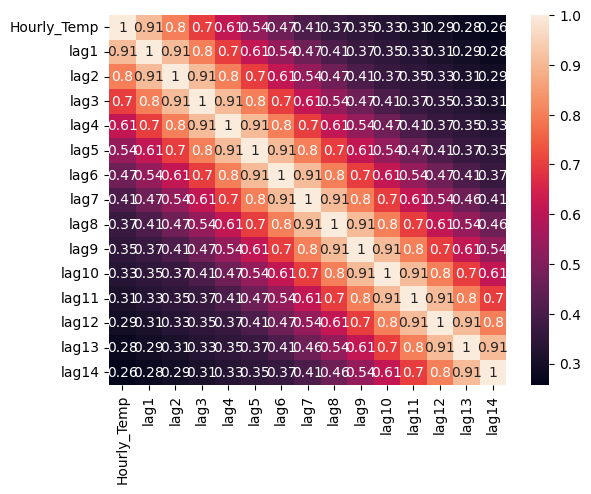

In [57]:
sns.heatmap(train.corr(), annot=True)

проверка корреляции с различными сдвигами

In [58]:
train['lag1'] = train['Hourly_Temp'].shift(1, axis = 0)
train['lag2'] = train['Hourly_Temp'].shift(2, axis = 0)
for i in range(3,15):
  string = f'lag{i}'
  train = train.drop(string, axis=1)
train

,Hourly_Temp,lag1,lag2
Datetime,,,
2022-01-04 00:00:00,20.867,NaN,NaN
2022-01-04 01:00:00,21.000,20.867,NaN
2022-01-04 02:00:00,20.867,21.000,20.867
2022-01-04 03:00:00,20.650,20.867,21.000
2022-01-04 04:00:00,20.400,20.650,20.867
...,...,...,...
2022-08-26 23:00:00,26.850,26.620,26.217
2022-08-27 00:00:00,27.017,26.850,26.620
2022-08-27 01:00:00,26.960,27.017,26.850


оставим сдвиг на 1 и на 2 знач.

<Axes: >

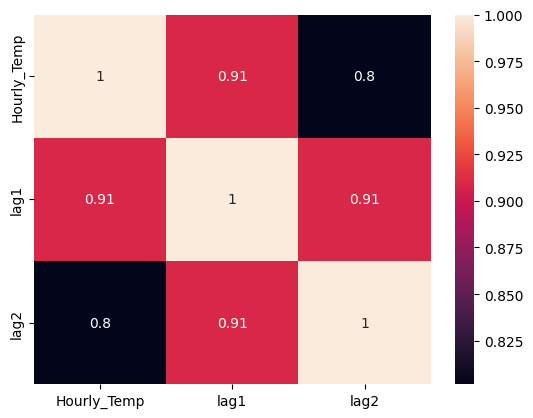

In [59]:
sns.heatmap(train.corr(), annot=True)

In [60]:
!pip install skforecast

In [61]:
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster

from sklearn.linear_model import LinearRegression

In [62]:
train.asfreq('D')

,Hourly_Temp,lag1,lag2
Datetime,,,
2022-01-04,20.867,NaN,NaN
2022-01-05,21.333,21.800,22.300
2022-01-06,26.500,23.600,12.950
2022-01-07,23.967,21.350,12.467
2022-01-08,26.750,26.200,16.133
...,...,...,...
2022-08-23,25.300,25.117,24.617
2022-08-24,26.133,25.840,25.633
2022-08-25,25.943,25.700,25.350


In [87]:
forecaster = ForecasterRecursive(
    regressor = LinearRegression(),
    lags = 1)

forecaster.fit(train['Hourly_Temp'])
forecaster

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ Series has a pandas DatetimeIndex without a frequency. The index will be replaced by │
│ a RangeIndex starting from 0 with a step of 1. To avoid this warning, set the        │
│ frequency of the DatetimeIndex using `y = y.asfreq('desired_frequency',              │
│ fill_value=np.nan)`.                                                                 │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1402    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [1] 
Window features: None 
Window size: 1 
Series name: Hourly_Temp 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 5643] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2025-06-12 13:02:44 
Last fit date: 2025-06-12 13:02:44 
Skforecast version: 0.16.0 
Python version: 3.11.13 
Forecaster id: None

In [88]:
steps = len(test)

y_pred = forecaster.predict(steps = steps)
y_pred.head()

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ `last_window` has a pandas DatetimeIndex without a frequency. The index will be      │
│ replaced by a RangeIndex starting from 0 with a step of 1. To avoid this warning,    │
│ set the frequency of the DatetimeIndex using `last_window =                          │
│ last_window.asfreq('desired_frequency', fill_value=np.nan)`.                         │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1446    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,pred
1,26.052622
2,25.627463
3,25.240709
4,24.888890
5,24.568852


In [89]:
y_pred.index=test.index

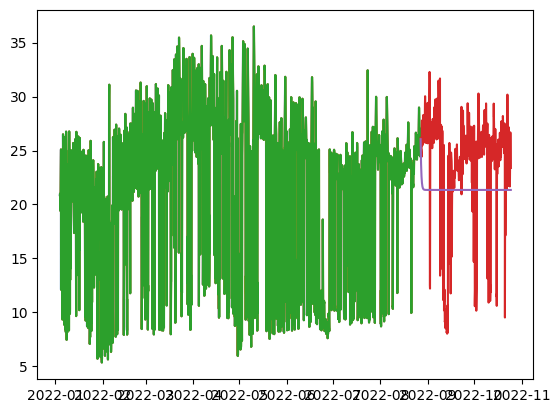

In [90]:
plt.plot(train)
plt.plot(test)
plt.plot(y_pred)

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [91]:
forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(),
    lags = 2)

forecaster.fit(train['Hourly_Temp'])
forecaster

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ Series has a pandas DatetimeIndex without a frequency. The index will be replaced by │
│ a RangeIndex starting from 0 with a step of 1. To avoid this warning, set the        │
│ frequency of the DatetimeIndex using `y = y.asfreq('desired_frequency',              │
│ fill_value=np.nan)`.                                                                 │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1402    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [1 2] 
Window features: None 
Window size: 2 
Series name: Hourly_Temp 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 5643] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-06-12 13:02:53 
Last fit date: 2025-06-12 13:02:55 
Skforecast version: 0.16.0 
Python version: 3.11.13 
Forecaster id: None

In [92]:
steps = len(test)

y_pred = forecaster.predict(steps = steps)
y_pred.head()

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ `last_window` has a pandas DatetimeIndex without a frequency. The index will be      │
│ replaced by a RangeIndex starting from 0 with a step of 1. To avoid this warning,    │
│ set the frequency of the DatetimeIndex using `last_window =                          │
│ last_window.asfreq('desired_frequency', fill_value=np.nan)`.                         │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1446    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,pred
2,19.826303
3,10.871070
4,11.124020
5,11.223830
6,11.652433


In [93]:
y_pred.index=test.index

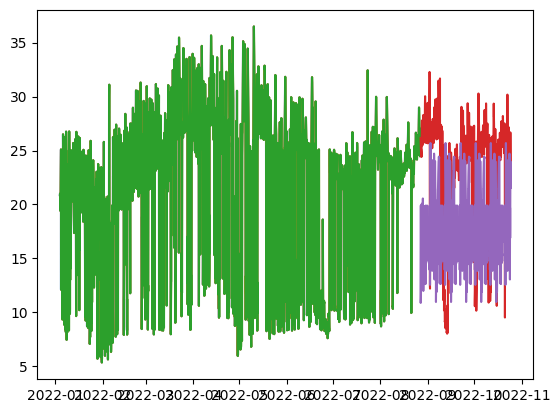

In [94]:
plt.plot(train)
plt.plot(test)
plt.plot(y_pred)

в результате были рассмотрены две модели для предсказания значений температуры во времени, лучше себя показала модель RandomForestRegressor